# Huấn Luyện Mô Hình — OLS Linear Regression
**Phương pháp:** Ordinary Least Squares (Bình phương nhỏ nhất)

**Mục tiêu:** Tìm $a$, $b$ sao cho $\hat{y} = ax + b$ khớp tốt nhất với dữ liệu.

**Tiêu chí tối ưu:**
$$\min_{a,b} \; L(a,b) = \sum_{i=1}^{n}(y_i - ax_i - b)^2$$

**Nghiệm giải tích (closed-form):**
$$a = \frac{n\sum x_i y_i - \sum x_i \sum y_i}{n\sum x_i^2 - (\sum x_i)^2}, \qquad b = \frac{\sum y_i - a\sum x_i}{n}$$

---
> **Output:** File `model.json` chứa tham số mô hình → dùng cho `demo.html`

## Bước 1 — Import thư viện & Nạp dữ liệu

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import json
import os
from datetime import datetime

# ── Nạp dataset ──
# Nếu chạy trên Google Colab, mount drive trước:
# from google.colab import drive
# drive.mount('/content/drive')
# path = '/content/drive/MyDrive/TRAIN2.xlsx'

path = 'TRAIN2.xlsx'   # <-- đổi đường dẫn nếu cần
df = pd.read_excel(path)

X = df['midterm'].values.astype(float)   # mảng điểm giữa kỳ
Y = df['final'].values.astype(float)     # mảng điểm cuối kỳ
n = len(X)

print(f'Đã nạp dataset: {n} mẫu')
print(f'   X (midterm) — min={X.min():.2f}, max={X.max():.2f}, mean={X.mean():.4f}')
print(f'   Y (final)   — min={Y.min():.2f}, max={Y.max():.2f}, mean={Y.mean():.4f}')
df.head()

Đã nạp dataset: 515 mẫu
   X (midterm) — min=0.03, max=9.96, mean=5.0381
   Y (final)   — min=2.03, max=9.97, mean=6.0325


,final,midterm
0,2.56,0.70
1,2.78,0.97
2,6.35,5.43
3,5.99,4.99
4,7.67,7.09


## Bước 2 — Giải thuật OLS (tích luỹ tổng, O(n))

In [9]:
# ── BƯỚC 2: Duyệt 1 lần, tích luỹ 4 giá trị — O(n) ──
sum_x  = 0.0
sum_y  = 0.0
sum_xy = 0.0
sum_x2 = 0.0

for i in range(n):
    sum_x  += X[i]
    sum_y  += Y[i]
    sum_xy += X[i] * Y[i]
    sum_x2 += X[i] * X[i]

print('📊 Kết quả tích luỹ tổng:')
print(f'   n      = {n}')
print(f'   Σx     = {sum_x:.4f}')
print(f'   Σy     = {sum_y:.4f}')
print(f'   Σxy    = {sum_xy:.4f}')
print(f'   Σx²    = {sum_x2:.4f}')

📊 Kết quả tích luỹ tổng:
   n      = 515
   Σx     = 2594.6400
   Σy     = 3106.7600
   Σxy    = 19179.7929
   Σx²    = 17481.3268


## Bước 3 — Tính nghiệm giải tích a, b (O(1))

In [10]:
# ── BƯỚC 3: Nghiệm closed-form — không lặp, O(1) ──
denom = n * sum_x2 - sum_x ** 2
a = (n * sum_xy - sum_x * sum_y) / denom
b = (sum_y - a * sum_x) / n

print('Công thức tính a:')
print(f'   a = [n·Σxy − Σx·Σy] / [n·Σx² − (Σx)²]')
print(f'   a = [{n}×{sum_xy:.2f} − {sum_x:.2f}×{sum_y:.2f}] / [{n}×{sum_x2:.2f} − {sum_x:.2f}²]')
print(f'   a = {a:.8f}')
print()
print(f'Công thức tính b:')
print(f'   b = (Σy − a·Σx) / n')
print(f'   b = ({sum_y:.2f} − {a:.6f}×{sum_x:.2f}) / {n}')
print(f'   b = {b:.8f}')
print()
print(f'Mô hình: ŷ = {a:.6f}·x + {b:.6f}')

Công thức tính a:
   a = [n·Σxy − Σx·Σy] / [n·Σx² − (Σx)²]
   a = [515×19179.79 − 2594.64×3106.76] / [515×17481.33 − 2594.64²]
   a = 0.80003889

Công thức tính b:
   b = (Σy − a·Σx) / n
   b = (3106.76 − 0.800039×2594.64) / 515
   b = 2.00183899

Mô hình: ŷ = 0.800039·x + 2.001839


## Bước 4 — Đánh giá mô hình (R², MAE, RMSE)

In [11]:
# ── BƯỚC 4: Tính ŷᵢ, residuals, các chỉ số đánh giá — O(n) ──
Y_pred   = a * X + b
residuals = Y - Y_pred

ss_res = np.sum(residuals ** 2)
ss_tot = np.sum((Y - Y.mean()) ** 2)

R2   = 1 - ss_res / ss_tot
MSE  = ss_res / n
RMSE = np.sqrt(MSE)
MAE  = np.mean(np.abs(residuals))

print('Đánh giá mô hình:')
print(f'   R²   = {R2:.8f}  ← càng gần 1 càng tốt')
print(f'   MAE  = {MAE:.8f}  ← sai số trung bình tuyệt đối')
print(f'   RMSE = {RMSE:.8f}  ← căn bậc hai MSE')
print(f'   MSE  = {MSE:.8f}  ← sai số bình phương trung bình')

Đánh giá mô hình:
   R²   = 0.99999852  ← càng gần 1 càng tốt
   MAE  = 0.00244368  ← sai số trung bình tuyệt đối
   RMSE = 0.00284646  ← căn bậc hai MSE
   MSE  = 0.00000810  ← sai số bình phương trung bình


## Bước 5 — Đồ thị tính toán

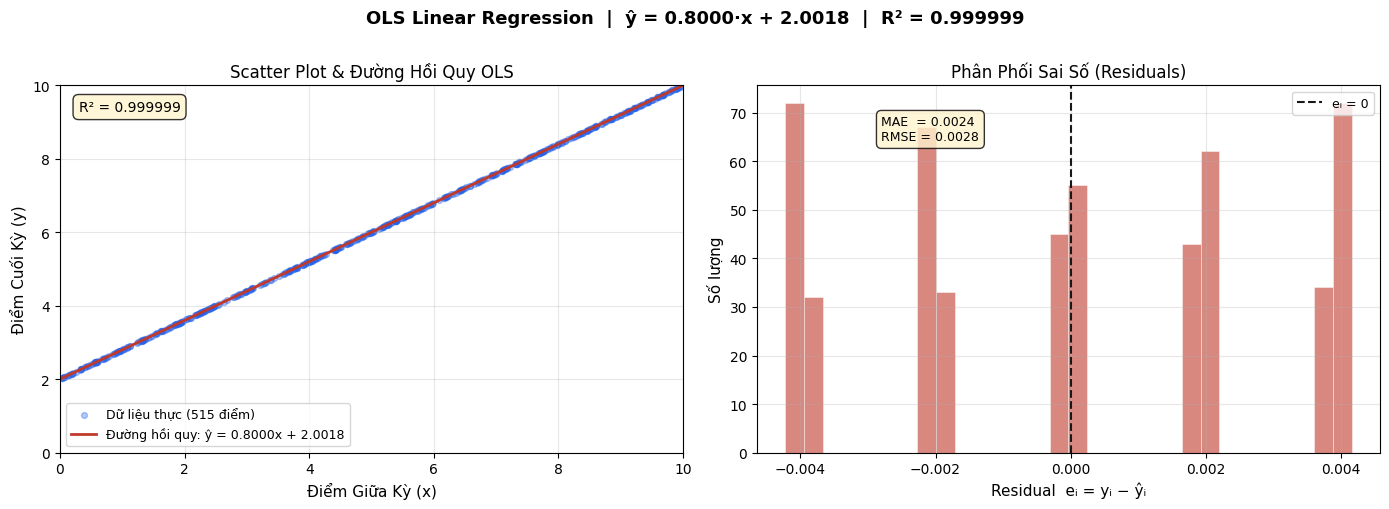

Đã lưu đồ thị: training_plot.png


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'OLS Linear Regression  |  ŷ = {a:.4f}·x + {b:.4f}  |  R² = {R2:.6f}',
             fontsize=13, fontweight='bold', y=1.01)

# ── ĐỒ THỊ 1: Scatter + đường hồi quy ──
ax1 = axes[0]
ax1.scatter(X, Y, alpha=0.35, s=18, color='#2563eb', label='Dữ liệu thực (515 điểm)')
x_line = np.linspace(0, 10, 200)
y_line = a * x_line + b
ax1.plot(x_line, y_line, color='#c0392b', linewidth=2,
         label=f'Đường hồi quy: ŷ = {a:.4f}x + {b:.4f}')
ax1.set_xlabel('Điểm Giữa Kỳ (x)', fontsize=11)
ax1.set_ylabel('Điểm Cuối Kỳ (y)', fontsize=11)
ax1.set_title('Scatter Plot & Đường Hồi Quy OLS', fontsize=12)
ax1.legend(fontsize=9)
ax1.set_xlim(0, 10); ax1.set_ylim(0, 10)
ax1.grid(True, alpha=0.3)
ax1.text(0.3, 9.3, f'R² = {R2:.6f}', fontsize=10,
         bbox=dict(boxstyle='round,pad=0.4', facecolor='#fff3cd', alpha=0.8))

# ── ĐỒ THỊ 2: Residual histogram ──
ax2 = axes[1]
ax2.hist(residuals, bins=30, color='#c0392b', alpha=0.6, edgecolor='white', linewidth=0.5)
ax2.axvline(0, color='#1a1714', linewidth=1.5, linestyle='--', label='eᵢ = 0')
ax2.set_xlabel('Residual  eᵢ = yᵢ − ŷᵢ', fontsize=11)
ax2.set_ylabel('Số lượng', fontsize=11)
ax2.set_title('Phân Phối Sai Số (Residuals)', fontsize=12)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)
ax2.text(ax2.get_xlim()[0]*0.8 + ax2.get_xlim()[1]*0.2,
         ax2.get_ylim()[1]*0.85 if ax2.get_ylim()[1] > 0 else 10,
         f'MAE  = {MAE:.4f}\nRMSE = {RMSE:.4f}',
         fontsize=9, bbox=dict(boxstyle='round,pad=0.4', facecolor='#fff3cd', alpha=0.8))

plt.tight_layout()
plt.savefig('training_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Đã lưu đồ thị: training_plot.png')

## Bước 6 — Xuất model.json

In [13]:
# ── BƯỚC 6: Xuất kết quả huấn luyện ra file model.json ──
model = {
    "model_name":   "OLS Linear Regression",
    "trained_at":   datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    "dataset":      "TRAIN2.xlsx",
    "n_samples":    int(n),
    "feature":      "midterm",
    "target":       "final",
    "parameters": {
        "a":  round(float(a), 8),
        "b":  round(float(b), 8)
    },
    "accumulators": {
        "sum_x":  round(float(sum_x),  4),
        "sum_y":  round(float(sum_y),  4),
        "sum_xy": round(float(sum_xy), 4),
        "sum_x2": round(float(sum_x2), 4)
    },
    "metrics": {
        "R2":   round(float(R2),   8),
        "MAE":  round(float(MAE),  8),
        "RMSE": round(float(RMSE), 8),
        "MSE":  round(float(MSE),  8)
    },
    "formula": f"y_hat = {a:.8f} * x + {b:.8f}"
}

with open('model.json', 'w', encoding='utf-8') as f:
    json.dump(model, f, indent=2, ensure_ascii=False)

print('Đã xuất: model.json')
print()
print(json.dumps(model, indent=2, ensure_ascii=False))

Đã xuất: model.json

{
  "model_name": "OLS Linear Regression",
  "trained_at": "2026-05-13 01:20:44",
  "dataset": "TRAIN2.xlsx",
  "n_samples": 515,
  "feature": "midterm",
  "target": "final",
  "parameters": {
    "a": 0.80003889,
    "b": 2.00183899
  },
  "accumulators": {
    "sum_x": 2594.64,
    "sum_y": 3106.76,
    "sum_xy": 19179.7929,
    "sum_x2": 17481.3268
  },
  "metrics": {
    "R2": 0.99999852,
    "MAE": 0.00244368,
    "RMSE": 0.00284646,
    "MSE": 8.1e-06
  },
  "formula": "y_hat = 0.80003889 * x + 2.00183899"
}
